- Adrián Marcelo Garza Morton 598817 & Patricio Dávila Santos 504056
- Inteligencia Artificial 2
- Final project: Sports Analytics using Deep Learning Models
- Dr. Andrés Hernández Gutiérrez
- 21/05/2026
- Universidad de Monterrey
- San Pedro Garza García, Nuevo León, México
- Damos nuestra palabra que hemos realizado esta actividad con integridad académica

En este notebook se implementa un pipeline inicial de detección de objetos para video aéreo de fútbol. El objetivo es detectar dos clases principales: jugadores y balón. Para esto se utiliza un modelo de detección basado en YOLOv8, un dataset etiquetado manualmente una preparación de datos, entrenamiento, validación, prueba, guardado del modelo e inferencia en frames no vistos.

Esta tarea se limita únicamente a detección y clasificación de objetos. Todavía no se implementa la parte de análisis deportivo, ya que en esta etapa el objetivo principal es demostrar que el pipeline técnico funciona correctamente.

Primero se instalan las librerías necesarias para trabajar con el pipeline. 'ultralytics' se utiliza para cargar, entrenar, validar y ejecutar inferencia con YOLOv8. 'opencv-python' permite leer el video y extraer frames. 'matplotlib' se usa para visualizar imágenes y resultados dentro del notebook. Finalmente, 'scikit-learn' se incluye como apoyo para posibles particiones o manipulación del dataset.

In [ ]:
!pip install ultralytics opencv-python matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.3 MB/s eta 0:00:00


Importación de librerías para la manipulación de archivos y directorios (`os`, `shutil`, `random`), el procesamiento y visualización de imágenes (`cv2`, `matplotlib`), la gestión del modelo de detección (`YOLO`) y la partición del dataset (`train_test_split`)

In [ ]:
import os
import cv2
import shutil
import random
import matplotlib.pyplot as plt

from ultralytics import YOLO
from sklearn.model_selection import train_test_split

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


Se monta Google Drive para trabajar directamente con los archivos del proyecto. Esto permite acceder al video original, guardar los frames extraídos, cargar el dataset exportado desde Roboflow y respaldar los pesos del modelo entrenado. Usar Drive ayuda a evitar que los archivos se pierdan cuando se reinicia la sesión de Google Colab.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Preparación de datos: extracción de frames del video

Configuración de rutas en Google Drive y extracción de 200 frames distribuidos equitativamente a lo largo del video. En lugar de tomar frames consecutivos, los frames distribuidos nos permite obtener ejemplos de diferentes momentos del partido, con variación en la posición de los jugadores, la ubicación del balón y la distribución de los objetos en la cancha.

In [ ]:
# Carpeta principal en Google Drive
base_path = "/content/drive/MyDrive/IA2_Final_Project"

# Ruta del video
video_path = os.path.join(base_path, "2023_05_05_15_02_22-players-and-ball-detection.mp4")

# Carpeta donde se guardarán los nuevos frames
output_folder = os.path.join(base_path, "frames_nuevos_final")
os.makedirs(output_folder, exist_ok=True)

# Abrir video
cap = cv2.VideoCapture(video_path)

# Total de frames
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print("Total de frames en el video:", total_frames)

# Frames que ya se habían extraído en la tarea 9
num_previous_frames = 200
previous_indices = [
    int(i * total_frames / num_previous_frames)
    for i in range(num_previous_frames)
]

# Queremos extraer frames nuevos
num_new_frames = 430

# Generamos más candidatos para poder saltarnos repetidos o cercanos
num_candidates = 1200
candidate_indices = [
    int(i * total_frames / num_candidates)
    for i in range(num_candidates)
]

# Distancia mínima respecto a frames anteriores
min_distance = 5

new_indices = []

for idx in candidate_indices:
    too_close = False

    for prev_idx in previous_indices:
        if abs(idx - prev_idx) <= min_distance:
            too_close = True
            break

    if not too_close:
        new_indices.append(idx)

    if len(new_indices) >= num_new_frames:
        break

count = 0

for frame_idx in new_indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()

    if ret:
        frame_name = f"new_frame_{count:04d}.jpg"
        frame_path = os.path.join(output_folder, frame_name)
        cv2.imwrite(frame_path, frame)
        count += 1

cap.release()

print("Frames nuevos extraídos:", count)
print("Frames guardados en:", output_folder)

Total de frames en el video: 3846
Frames nuevos extraídos: 430
Frames guardados en: /content/drive/MyDrive/IA2_Final_Project/frames_nuevos_final


## Etiquetado de datos con Roboflow

Para el etiquetado de imágenes se utilizó Roboflow, una herramienta que permite crear datasets de detección de objetos mediante cajas delimitadoras. En Roboflow se subieron los frames extraídos del video y se etiquetaron manualmente los objetos de interés.

Las clases utilizadas fueron:
- `Ball`, que representa el balón.
- `Person`, que representa a los jugadores.

Aunque los nombres exportados por Roboflow aparecen como Ball y Person, estos corresponden directamente a las clases ball y player.

In [ ]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 129.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


## Carga del dataset exportado desde Roboflow

Después de etiquetar las imágenes en Roboflow, el dataset fue exportado en formato YOLOv8 y guardado en Google Drive. En esta celda se define la ruta hacia la carpeta exportada y se revisa su contenido para confirmar que el dataset esté disponible dentro del notebook.

El formato YOLOv8 es compatible con Ultralytics y organiza los datos en carpetas de entrenamiento, validación y prueba, junto con un archivo data.yaml que indica las rutas y los nombres de las clases.

In [ ]:
# Carpeta principal en Google Drive
base_path = "/content/drive/MyDrive/IA2_Final_Project"

# Ruta del video
video_path = os.path.join(base_path, "2023_05_05_15_02_22-players-and-ball-detection.mp4")

# Nueva carpeta del dataset exportado desde Roboflow
dataset_path = "/content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8"

# Revisar contenido de la carpeta
print(os.listdir(dataset_path))


['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'test', 'train', 'valid']


Verificación de la estructura del dataset y lectura del `data.yaml` para confirmar la configuración de las clases.:


In [ ]:
# Archivo YAML del dataset
data_yaml = os.path.join(dataset_path, "data.yaml")

# Revisar contenido del dataset
print(os.listdir(dataset_path))

# Revisar contenido del YAML
with open(data_yaml, "r") as file:
    print(file.read())

['README.roboflow.txt', 'README.dataset.txt', 'data.yaml', 'test', 'train', 'valid']
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 2
names: ['Ball', 'Person']

roboflow:
  workspace: adrians-workspace-dwk1u
  project: my-first-project-tazwu
  version: 2
  license: CC BY 4.0
  url: https://universe.roboflow.com/adrians-workspace-dwk1u/my-first-project-tazwu/dataset/2


## División del dataset

El dataset fue dividido en tres subconjuntos: entrenamiento, validación y prueba. La división se realizó desde Roboflow usando una proporción de 70% para entrenamiento, 20% para validación y 10% para prueba.

El conjunto de entrenamiento se utiliza para ajustar los pesos del modelo. El conjunto de validación permite monitorear el desempeño durante el entrenamiento. Finalmente, el conjunto de prueba se reserva para evaluar el modelo con imágenes que no fueron usadas para entrenar ni validar.

## Selección del modelo

Para esta tarea se seleccionó YOLOv8n, la versión nano de YOLOv8. Este modelo fue elegido porque ofrece una buena combinación entre velocidad, facilidad de implementación y rendimiento. Además, es adecuado para una primera implementación del pipeline, ya que permite entrenar y hacer inferencia de manera rápida en Google Colab.

El modelo se utiliza con pesos preentrenados, por lo que no se entrena desde cero. Esto corresponde a transferencia de aprendizaje, ya que se parte de un modelo previamente entrenado y se ajusta al dataset específico del proyecto. Esta decisión se basa en la investigación anterior, donde YOLOv8 fue identificado como la opción de preferencia por su rapidez y facilidad de uso.

## Entrenamiento del modelo

En esta sección se entrena el modelo YOLOv8n utilizando el dataset etiquetado. El entrenamiento se realiza con pesos preentrenados y se ajusta el modelo a las dos clases del proyecto: Ball y Person.

Los parámetros principales usados fueron:
- Modelo: YOLOv8n.
- Pesos preentrenados: sí.
- Número de épocas: 100.
- Tamaño de imagen: 640.
- Batch size: 8.
- Formato de dataset: YOLOv8.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=data_yaml,
    epochs=100,
    imgsz=640,
    batch=8,
    device=0,
    name="final_soccer_yolov8n_player_ball"
)

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=final_soccer_yolov8n_player_ball, nbs=64, nms=False, op

Como se puede observar en los resultados del entrenamiento, el modelo logró completar las 100 épocas correctamente usando GPU. Las métricas muestran que el modelo aprendió a detectar los objetos del dataset, especialmente la clase Person, que obtuvo mejores resultados que la clase Ball. Esto era esperado, ya que los jugadores aparecen con mayor frecuencia y ocupan más espacio en la imagen, mientras que el balón es más pequeño y difícil de identificar en un video aéreo.

## Validación y prueba del modelo

Después del entrenamiento, se carga el mejor modelo guardado automáticamente por YOLOv8, conocido como best.pt. Este archivo contiene los pesos del modelo que obtuvo el mejor desempeño durante el entrenamiento.

Posteriormente, el modelo se evalúa sobre el conjunto de prueba. Este paso es importante porque permite medir el desempeño del modelo en imágenes que no fueron utilizadas durante el entrenamiento. En detección de objetos, las métricas principales no son solamente accuracy, sino también precision, recall, mAP50 y mAP50-95, ya que el modelo debe clasificar correctamente los objetos y también localizar sus cajas delimitadoras.

In [ ]:
import shutil

# Carpeta donde YOLO guardó el entrenamiento en Colab
run_folder = "/content/runs/detect/final_soccer_yolov8n_player_ball"

# Carpeta destino en Google Drive
drive_output_folder = "/content/drive/MyDrive/IA2_Final_Project/runs/final_soccer_yolov8n_player_ball"

# Copiar toda la carpeta del entrenamiento a Drive
shutil.copytree(run_folder, drive_output_folder, dirs_exist_ok=True)

print("Entrenamiento guardado en Drive:")
print(drive_output_folder)

Entrenamiento guardado en Drive:
/content/drive/MyDrive/IA2_Final_Project/runs/final_soccer_yolov8n_player_ball


In [ ]:
# Carpeta destino en Drive
weights_drive_folder = "/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado"
os.makedirs(weights_drive_folder, exist_ok=True)

# Rutas de pesos
best_model = os.path.join(run_folder, "weights", "best.pt")
last_model = os.path.join(run_folder, "weights", "last.pt")

# Copiar a Drive
shutil.copy(best_model, os.path.join(weights_drive_folder, "best_final_soccer_yolov8n.pt"))
shutil.copy(last_model, os.path.join(weights_drive_folder, "last_final_soccer_yolov8n.pt"))

print("Modelos guardados en Drive.")

Modelos guardados en Drive.


In [ ]:
best_model = YOLO("/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado/best_final_soccer_yolov8n.pt")

## Evaluación en conjunto de prueba

Después del entrenamiento, se carga el mejor modelo guardado en Google Drive y se evalúa sobre el conjunto de prueba. Este conjunto no fue utilizado durante el entrenamiento, por lo que permite medir el desempeño del modelo en imágenes nuevas. Se reportan precision, recall y F1-score por clase.

In [ ]:
model_path = "/content/drive/MyDrive/IA2_Final_Project/modelo_entrenado/best_final_soccer_yolov8n.pt"
best_model = YOLO(model_path)

# Evaluar en el conjunto de prueba
metrics = best_model.val(
    data=data_yaml,
    split="test"
)

# Extraer precision y recall por clase
precision = metrics.box.p
recall = metrics.box.r

# Calcular F1-score por clase
f1 = 2 * (precision * recall) / (precision + recall + 1e-9)

# Mostrar resultados por clase
class_names = metrics.names

for i, class_name in class_names.items():
    print(f"Clase: {class_name}")
    print(f"Precision: {precision[i]:.4f}")
    print(f"Recall: {recall[i]:.4f}")
    print(f"F1-score: {f1[i]:.4f}")
    print()

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 0.0±0.0 MB/s, size: 46.5 KB)
val: Scanning /content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8/test/labels... 62 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 62/62 1.7s/it 1:44
val: New cache created: /content/drive/MyDrive/IA2_Final_Project/My First Project.v2-2.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.0it/s 3.8s
                   all         62        808      0.592      0.697      0.606      0.372
                  Ball         60         60      0.428      0.462       0.32      0.198
                Person         62        748      0.756      0.932      0.892      0.546
Speed: 11.4ms preprocess, 11.8ms inference, 0.0ms loss, 6.2ms postprocess per ima

Como se puede observar en los resultados del conjunto de prueba, el modelo obtuvo un desempeño general aceptable para una primera versión del sistema. La clase Person tuvo mejores resultados, con una precisión de 0.7565, recall de 0.9318 y F1-score de 0.8350, lo que indica que el modelo logra detectar a la mayoría de los jugadores en los frames no vistos. En cambio, la clase Ball obtuvo una precisión de 0.4281, recall de 0.4616 y F1-score de 0.4442. Esto confirma que la detección del balón sigue siendo el reto principal, debido a que es un objeto pequeño, aparece con menos frecuencia y puede confundirse con líneas, sombras u otros elementos de la cancha.

Definir cancha, media cancha y áreas de penal

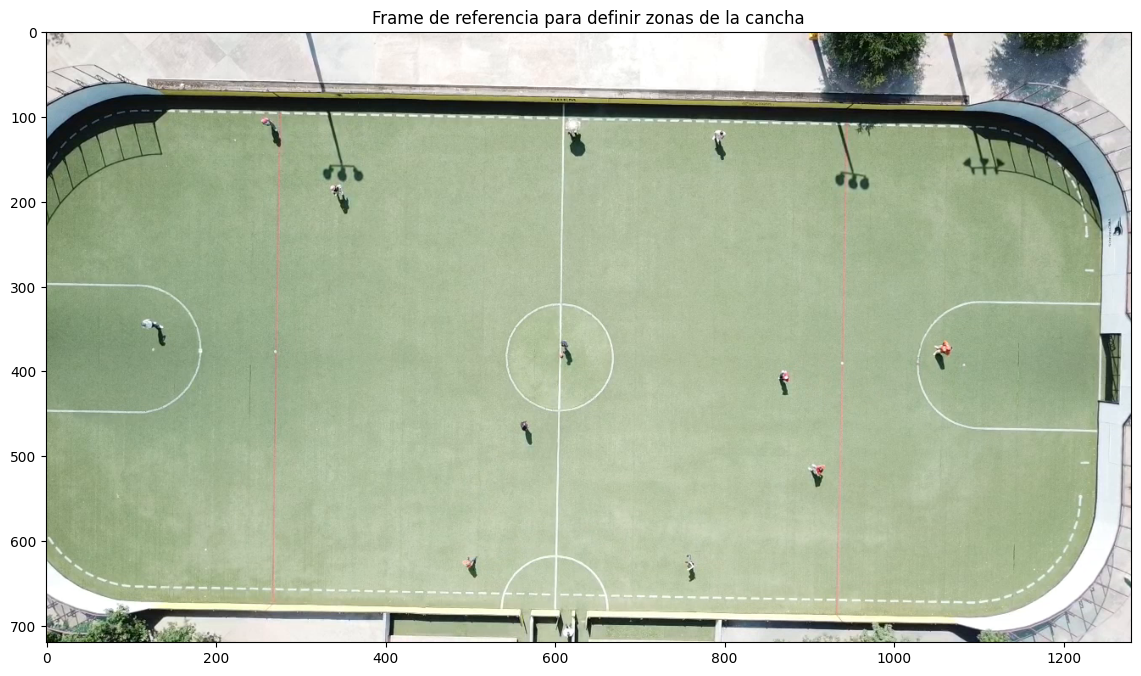

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Abrir video
cap = cv2.VideoCapture(video_path)

# Leer un frame de referencia
cap.set(cv2.CAP_PROP_POS_FRAMES, 100)
ret, frame = cap.read()

cap.release()

# Convertir de BGR a RGB para mostrar correctamente con matplotlib
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(frame_rgb)
plt.axis("on")
plt.title("Frame de referencia para definir zonas de la cancha")
plt.show()

In [ ]:
import numpy as np

# Polígono aproximado de la cancha completa
court_polygon = np.array([
    [75, 95],      # esquina superior izquierda
    [1165, 95],    # esquina superior derecha
    [1245, 205],   # curva derecha superior
    [1240, 600],   # lado derecho
    [1185, 680],   # curva derecha inferior
    [65, 675],     # esquina inferior izquierda
    [5, 605],      # curva izquierda inferior
    [5, 225]       # curva izquierda superior
], dtype=np.int32)

# Línea de media cancha aproximada
midline_x = 605

# Área de penal izquierda aproximada
left_penalty_polygon = np.array([
    [5, 290],
    [190, 290],
    [190, 455],
    [5, 455]
], dtype=np.int32)

# Área de penal derecha aproximada
right_penalty_polygon = np.array([
    [1035, 305],
    [1240, 305],
    [1240, 455],
    [1035, 455]
], dtype=np.int32)

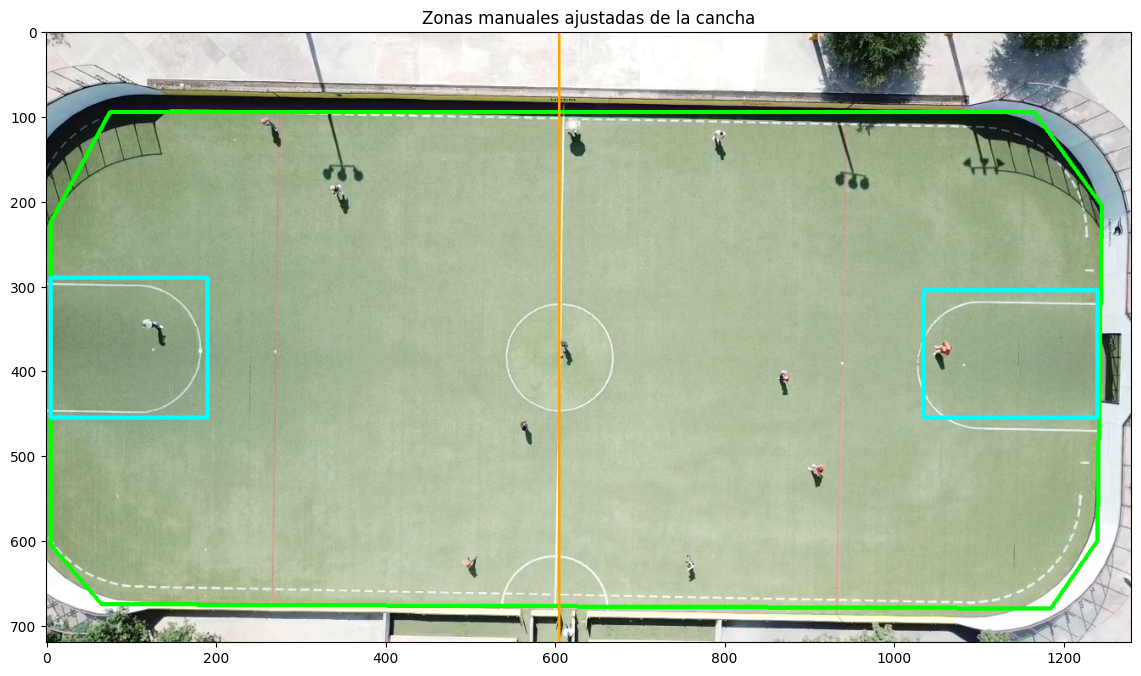

In [ ]:
# Copiar frame para dibujar encima
frame_zones = frame.copy()

# Dibujar cancha
cv2.polylines(frame_zones, [court_polygon], True, (0, 255, 0), 3)

# Dibujar línea de media cancha
height = frame_zones.shape[0]
cv2.line(frame_zones, (midline_x, 0), (midline_x, height), (0, 165, 255), 2)

# Dibujar áreas de penal
cv2.polylines(frame_zones, [left_penalty_polygon], True, (255, 255, 0), 3)
cv2.polylines(frame_zones, [right_penalty_polygon], True, (255, 255, 0), 3)

# Mostrar resultado
frame_zones_rgb = cv2.cvtColor(frame_zones, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(frame_zones_rgb)
plt.axis("on")
plt.title("Zonas manuales ajustadas de la cancha")
plt.show()

Las coordenadas de la cancha fueron definidas manualmente a partir de un frame de referencia del video. Debido a que la cámara aérea permanece fija durante la secuencia, estas regiones pueden reutilizarse para todos los frames. Se definió un polígono para representar los límites generales de la cancha, una línea vertical para dividir el campo en lado izquierdo y derecho, y dos polígonos rectangulares aproximados para representar las áreas de penal. Estas zonas se utilizarán junto con los centroides de las detecciones para calcular las analíticas visuales.

---------------------------------------------
--------------------------------------------
A PARTR DE AQUI, LO DE ABAJO ES DE LA TAREA 9. LUEGO VEO QUE HACER CON ESO.

In [ ]:
# Cargar el mejor modelo entrenado
best_model = YOLO("/content/runs/detect/soccer_yolov8n_player_ball-2/weights/best.pt")

# Evaluar en el conjunto de prueba
test_results = best_model.val(
    data=data_yaml,
    split="test"
)

Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.8±0.3 ms, read: 0.1±0.0 MB/s, size: 46.8 KB)
val: Scanning /content/drive/MyDrive/IA2_Tarea9/My First Project.v1-1.yolov8/test/labels... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 1.7s/it 31.4s
val: New cache created: /content/drive/MyDrive/IA2_Tarea9/My First Project.v1-1.yolov8/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.4it/s 1.4s
                   all         19        250       0.54      0.501      0.475      0.265
                  Ball         19         19      0.269      0.105     0.0948     0.0503
                Person         19        231      0.812      0.896      0.856      0.479
Speed: 15.1ms preprocess, 25.8ms inference, 0.0ms loss, 2.8ms postprocess per image
Results sa

Una vez finalizado el entrenamiento, YOLOv8 guarda automáticamente los pesos del modelo en el entorno local de Colab. Sin embargo, estos archivos pueden perderse si se reinicia la sesión. Por esta razón, en esta sección se copia el archivo best.pt a Google Drive.

El archivo best.pt representa el mejor modelo obtenido durante el entrenamiento y puede reutilizarse después para continuar entrenando, validar nuevamente o realizar inferencia sobre nuevas imágenes o videos.

In [ ]:
import shutil

# Carpeta donde se guardará el modelo en Drive
model_output_folder = "/content/drive/MyDrive/IA2_Tarea9/modelo_entrenado"
os.makedirs(model_output_folder, exist_ok=True)

# Ruta del mejor modelo entrenado
source_model = "/content/runs/detect/soccer_yolov8n_player_ball-2/weights/best.pt"

# Ruta final en Drive
destination_model = os.path.join(model_output_folder, "best_soccer_yolov8n.pt")

# Copiar modelo
shutil.copy(source_model, destination_model)

print("Modelo guardado en:", destination_model)

Modelo guardado en: /content/drive/MyDrive/IA2_Tarea9/modelo_entrenado/best_soccer_yolov8n.pt


Además del mejor modelo, también se guarda el archivo last.pt. Este archivo contiene los pesos correspondientes a la última época del entrenamiento.

In [ ]:
source_last = "/content/runs/detect/soccer_yolov8n_player_ball-2/weights/last.pt"
destination_last = os.path.join(model_output_folder, "last_soccer_yolov8n.pt")

shutil.copy(source_last, destination_last)

print("Último modelo guardado en:", destination_last)

Último modelo guardado en: /content/drive/MyDrive/IA2_Tarea9/modelo_entrenado/last_soccer_yolov8n.pt


# **Hacer inferencia en 10 frames no vistos**

Selección de 10 imágenes del conjunto de prueba para realizar la demostración de inferencia y validar visualmente la detección de jugadores y el balón.

El resultado de la inferencia se guarda automáticamente en una carpeta de resultados de YOLOv8. Cada imagen generada contiene las cajas delimitadoras, la clase detectada y el nivel de confianza de cada predicción.


In [ ]:
test_images_path = "/content/drive/MyDrive/IA2_Tarea9/My First Project.v1-1.yolov8/test/images"

test_images = [
    os.path.join(test_images_path, img)
    for img in os.listdir(test_images_path)
    if img.endswith((".jpg", ".png", ".jpeg"))
]

# Seleccionar 10 imágenes
sample_test_images = test_images[:10]

print("Frames seleccionados para inferencia:", len(sample_test_images))

Frames seleccionados para inferencia: 10



Carga del modelo final desde Google Drive y ejecución de inferencia sobre diez frames no vistos, utilizando un umbral de confianza de 0.25 para visualizar las detecciones obtenidas.



In [ ]:
# Cargar modelo entrenado desde Drive
best_model = YOLO("/content/drive/MyDrive/IA2_Tarea9/modelo_entrenado/best_soccer_yolov8n.pt")

# Ejecutar inferencia en 10 frames no vistos
inference_results = best_model.predict(
    source=sample_test_images,
    save=True,
    conf=0.25,
    name="inference_10_unseen_frames"
)


0: 640x640 14 Persons, 7.5ms
1: 640x640 1 Ball, 15 Persons, 7.5ms
2: 640x640 15 Persons, 7.5ms
3: 640x640 13 Persons, 7.5ms
4: 640x640 15 Persons, 7.5ms
5: 640x640 14 Persons, 7.5ms
6: 640x640 14 Persons, 7.5ms
7: 640x640 1 Ball, 12 Persons, 7.5ms
8: 640x640 14 Persons, 7.5ms
9: 640x640 15 Persons, 7.5ms
Speed: 3.4ms preprocess, 7.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/inference_10_unseen_frames


## Visualización de resultados de inferencia

Visualización de los resultados de detección procesando las imágenes desde la carpeta de predicción con OpenCV y Matplotlib para mostrar los cuadros delimitadores en los diez frames seleccionados.

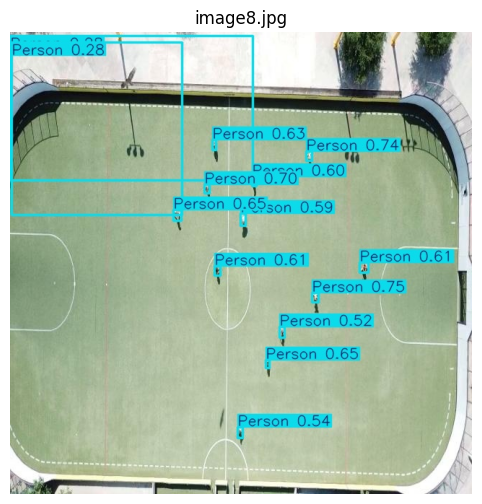

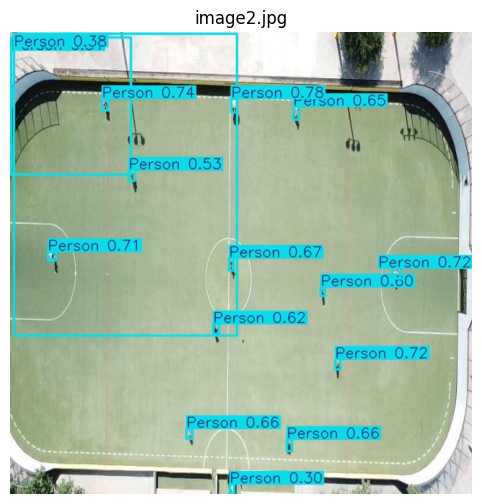

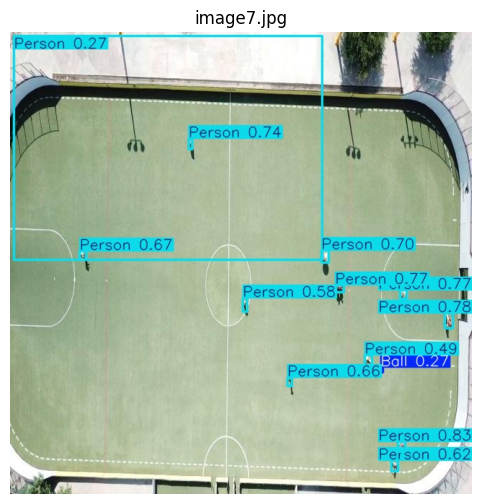

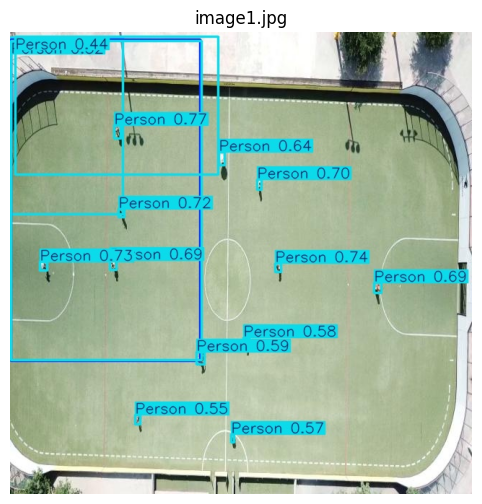

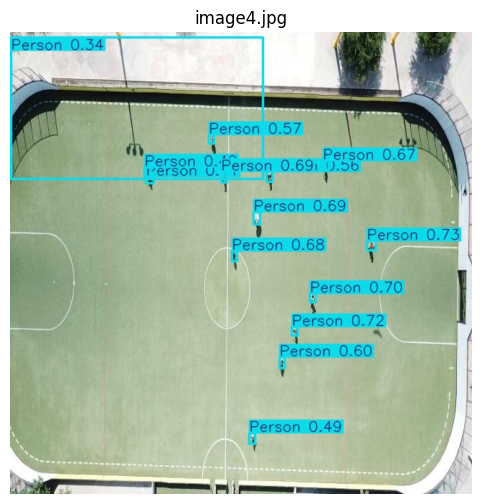

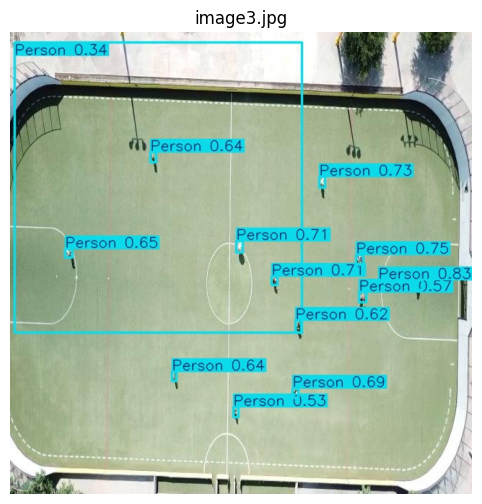

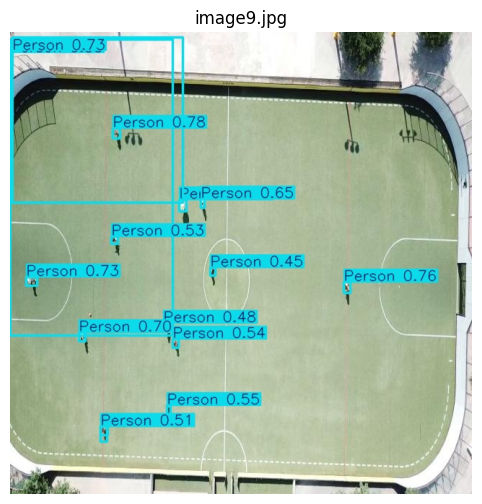

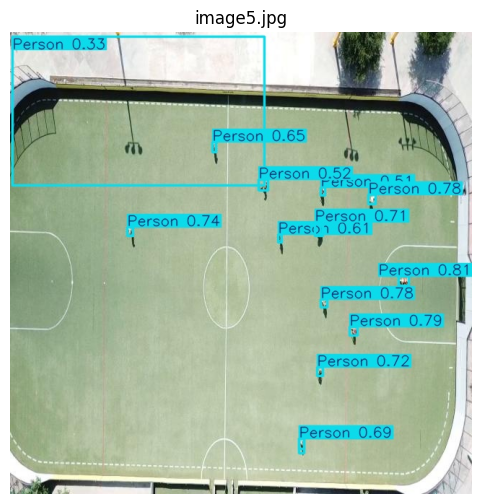

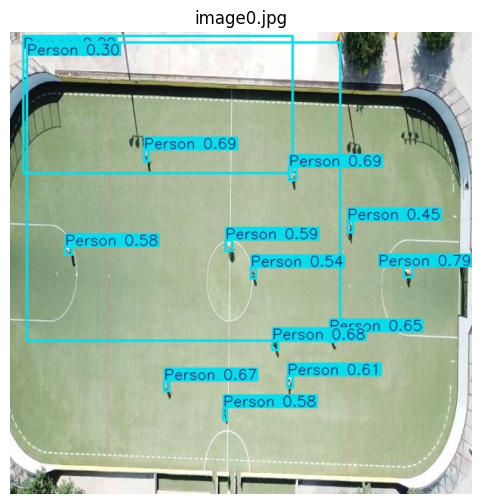

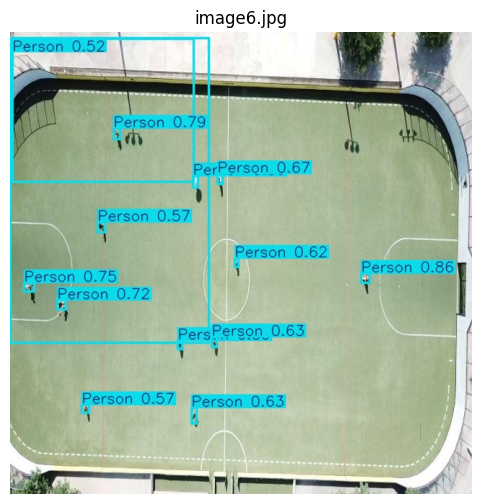

In [ ]:
import cv2
import matplotlib.pyplot as plt

predicted_folder = "/content/runs/detect/inference_10_unseen_frames"

predicted_images = [
    os.path.join(predicted_folder, img)
    for img in os.listdir(predicted_folder)
    if img.endswith((".jpg", ".png", ".jpeg"))
]

for img_path in predicted_images[:10]:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
    plt.show()

Como se puede observar en los resultados de inferencia, el modelo logra detectar correctamente a la mayoría de los jugadores dentro de la cancha. Las cajas delimitadoras de la clase Person aparecen en diferentes zonas del campo y con niveles de confianza aceptables, lo cual confirma que el modelo aprendió a identificar jugadores desde una vista aérea.

Sin embargo, también se observa que la detección del balón sigue siendo más complicada. En una de las imágenes sí se detecta la clase Ball, pero con una confianza baja de 0.27. Esto indica que el modelo comienza a reconocer el balón, pero todavía no lo hace de forma consistente. Este comportamiento coincide con los resultados de validación, donde la clase Ball tuvo menor desempeño que la clase Person.

## Explicacion de los resultados

Después de entrenar YOLOv8n durante 100 épocas, el modelo obtuvo una precisión general de 0.650, un recall de 0.508, un mAP50 de 0.521 y un mAP50-95 de 0.281 en el conjunto de validación. Estos resultados muestran que el modelo sí logró aprender a detectar objetos en las imágenes, aunque todavía tiene áreas importantes de mejora. Al analizar los resultados por clase, se observa que el modelo detecta mucho mejor a las personas que al balón. Para la clase Person, el modelo obtuvo un recall alto, lo cual indica que logró encontrar la mayoría de los jugadores presentes en los fotogramas. En cambio, la clase Ball tuvo un recall bajo, lo que significa que el modelo no detectó muchos de los balones reales presentes en las imágenes.

Este resultado era esperado, ya que el balón es mucho más pequeño que los jugadores, aparece con menos frecuencia en el dataset y puede confundirse fácilmente con líneas de la cancha, sombras u otros elementos visuales. Por lo tanto, el modelo actual funciona como una primera versión válida del pipeline, pero todavía necesita mejoras para detectar mejor el balón. En futuras iteraciones sería conveniente agregar más ejemplos etiquetados del balón, utilizar imágenes con mayor resolución y aplicar estrategias de aumento de datos enfocadas en objetos pequeños.

## Conclusión

En este notebook se implementó correctamente un pipeline inicial de detección de objetos para análisis de video aéreo de fútbol. Se seleccionó YOLOv8n como modelo base y se utilizó transferencia de aprendizaje a partir de pesos preentrenados. El dataset fue preparado con dos clases principales, Ball y Person, y posteriormente se entrenó, validó y guardó el modelo para poder reutilizarlo en etapas posteriores del proyecto.

Los resultados muestran que el modelo tiene un desempeño adecuado para detectar jugadores, pero todavía presenta limitaciones importantes en la detección del balón. Esto se debe principalmente al tamaño reducido del balón, su movimiento rápido y la menor cantidad de ejemplos etiquetados disponibles para esa clase. Como siguiente mejora, sería recomendable ampliar el dataset con más fotogramas donde el balón sea visible, mejorar el balance entre clases y probar configuraciones como mayor resolución de entrada o técnicas específicas para mejorar la detección de objetos pequeños.

## Limitaciones y mejoras propuestas

Una de las principales limitaciones del modelo es la detección del balón, ya que es un objeto pequeño, aparece con menos frecuencia en el dataset y puede confundirse con otros elementos de la cancha. Además, el dataset utilizado todavía es reducido, por lo que el modelo puede no generalizar bien a otros videos o condiciones de iluminación. Como mejora, se propone agregar más frames etiquetados, especialmente con ejemplos claros del balón, aumentar la cantidad de datos de entrenamiento y probar una resolución mayor o técnicas enfocadas en objetos pequeños para mejorar la precisión del detector.

## Hallazgo Adicional


Nos dimos cuenta que al empezar el proceso de entrenamiento mediantes épocas, la cantidad de tiempo por cada una de ellas era enorme, consideramos cambiar de CPU a GPU como un intento en el que estábamos muy semi-confiados, para nuestra sorpresa el cambio incrementó la velocidad de manera increíble; De completar una época en 2:30 minutos, el programa pasaba una cada una en 8 segundos.

 Investigando como complemento a nuestra actividad encontramos que: Las épocas en una red neuronal se entrenan mucho más rápido con una GPU porque el entrenamiento consiste principalmente en hacer enormes cantidades de operaciones matemáticas repetitivas, como multiplicaciones de matrices, y las GPUs están diseñadas para ejecutar miles de esas operaciones en paralelo al mismo tiempo, mientras que una CPU tiene pocos núcleos optimizados para tareas más generales y secuenciales; por eso, durante el entrenamiento de modelos grandes, una GPU puede procesar los cálculos de la red neuronal muchísimo más rápido que una CPU.

CPU:  Ryzen 7 7700X, GPU:RTX 5070
